# Steady-state heat equation on a U-shaped domain

**PDE:**  $-\Delta u = 0$  (Laplace / steady-state heat)

**Domain:**  $[0,2]\times[0,2]$ minus an inner rectangular notch $(x\in(0.6,1.4),\; y>0.8)$

```
  ┌────┐        ┌────┐
  │    │        │    │
  │    │  notch │    │
  │    └────────┘    │
  │                  │
  └──────────────────┘
```

**Boundary conditions:**
- $u = 1$ on the **left-arm top** ($y=2,\; x\in[0,0.6]$) — hot
- $u = 0$ everywhere else — cold

**Method:**  Weak-form PINN with a Graph Neural Network (`GNNMeshNetwork`) on a triangulated mesh.

## 1. Imports & environment

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
os.environ.setdefault("PINNS_BACKEND", "jax")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from collections import Counter

import pygmsh

import jax
import jax.numpy as jnp

from pinns import DomainMesh, GNNMeshNetwork, FNN
from pinns.backends.jax import Trainer
from pinns.problem_weak import ProblemWeak


## 2. Build the U-shaped triangulated mesh

In [2]:
# Geometry parameters
X_MAX   = 2.0
Y_MAX   = 2.0
NOTCH_X = (0.6, 1.4)
NOTCH_Y = 0.8
MESH_SIZE = 0.12   # target edge length

# Helper: point-in-domain test (used later for the dense evaluation grid)
def in_u_shape(pts: np.ndarray) -> np.ndarray:
    x, y   = pts[:, 0], pts[:, 1]
    in_box = (x >= 0) & (x <= X_MAX) & (y >= 0) & (y <= Y_MAX)
    in_cut = (x > NOTCH_X[0]) & (x < NOTCH_X[1]) & (y > NOTCH_Y)
    return in_box & ~in_cut

# ── Build the U-shape as a closed polygon and mesh it with gmsh/pygmsh ────
#
# The polygon follows the U contour exactly — gmsh generates a *constrained*
# triangulation that respects every boundary edge:
#
#   (0,0) → (2,0) → (2,2) → (1.4,2) → (1.4,0.8)
#         → (0.6,0.8) → (0.6,2) → (0,2) → (0,0)

u_polygon = [
    [0.0,        0.0      ],
    [X_MAX,      0.0      ],
    [X_MAX,      Y_MAX    ],
    [NOTCH_X[1], Y_MAX    ],
    [NOTCH_X[1], NOTCH_Y  ],
    [NOTCH_X[0], NOTCH_Y  ],
    [NOTCH_X[0], Y_MAX    ],
    [0.0,        Y_MAX    ],
]

with pygmsh.geo.Geometry() as geom:
    geom.add_polygon(u_polygon, mesh_size=MESH_SIZE)
    mesh = geom.generate_mesh(dim=2, verbose=False)

# Extract triangular elements and vertex coordinates
verts = mesh.points[:, :2].copy()                        # (n_nodes, 2)
faces = mesh.cells_dict["triangle"].astype(np.int64)     # (n_faces, 3)

# Remove unused vertices (gmsh sometimes adds extras)
used        = np.unique(faces)
remap       = np.full(len(verts), -1, dtype=np.int64)
remap[used] = np.arange(len(used))
verts       = verts[used]
faces       = remap[faces]

print(f"Mesh: {len(verts)} nodes, {len(faces)} triangles")


Mesh: 311 nodes, 532 triangles


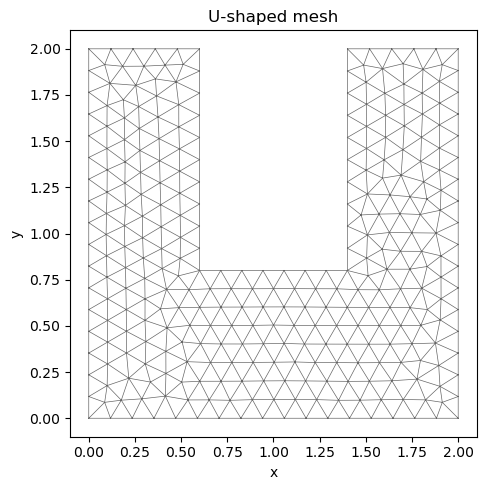

In [3]:
# Visualise the mesh
fig, ax = plt.subplots(figsize=(5, 5))
tri_vis = mtri.Triangulation(verts[:, 0], verts[:, 1], faces)
ax.triplot(tri_vis, "k-", lw=0.5, alpha=0.6)
ax.set_aspect("equal")
ax.set_title("U-shaped mesh")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## 3. Identify boundary nodes & assign BCs

In [4]:
# Find boundary vertices (edges shared by only one triangle)
edge_count = Counter()
for tri_idx in faces:
    for i in range(3):
        e = tuple(sorted([tri_idx[i], tri_idx[(i + 1) % 3]]))
        edge_count[e] += 1

boundary_verts_idx = set()
for (v0, v1), cnt in edge_count.items():
    if cnt == 1:
        boundary_verts_idx.update([v0, v1])
boundary_verts_idx = np.array(sorted(boundary_verts_idx))

is_boundary = np.zeros(len(verts), dtype=bool)
is_boundary[boundary_verts_idx] = True

# Hot BC: nodes exactly on the top edge of the left arm
# Use half-mesh-size tolerance to snap cleanly to y=Y_MAX and x<=NOTCH_X[0]
tol = MESH_SIZE / 2        # ~0.06, tight enough to select only the top edge
is_hot = (verts[:, 1] >= Y_MAX - tol) & (verts[:, 0] <= NOTCH_X[0] + tol)
is_hot = is_hot & is_boundary

print(f"Hot nodes  (u=1): {is_hot.sum()}")
print(f"Cold nodes (u=0): {(is_boundary & ~is_hot).sum()}")


Hot nodes  (u=1): 6
Cold nodes (u=0): 82


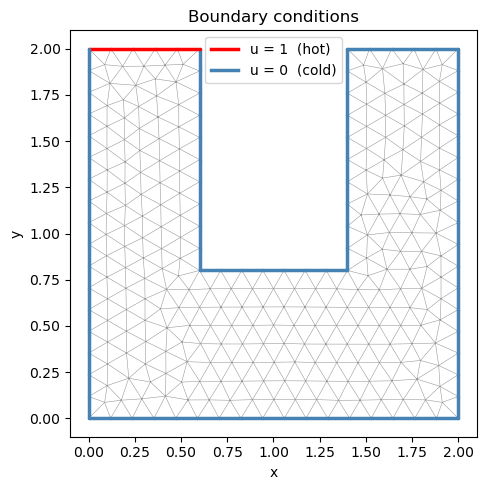

In [5]:
# Visualise BC edges
fig, ax = plt.subplots(figsize=(5, 5))
ax.triplot(tri_vis, "k-", lw=0.4, alpha=0.4)

for (v0, v1), cnt in edge_count.items():
    if cnt == 1:  # boundary edge
        xs = [verts[v0, 0], verts[v1, 0]]
        ys = [verts[v0, 1], verts[v1, 1]]
        # Edge is "hot" if both endpoints are hot nodes
        color = "red" if (is_hot[v0] and is_hot[v1]) else "steelblue"
        ax.plot(xs, ys, color=color, lw=2.5, solid_capstyle="round")

# Legend proxies
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color="red",       lw=2.5, label="u = 1  (hot)"),
    Line2D([0], [0], color="steelblue", lw=2.5, label="u = 0  (cold)"),
])
ax.set_aspect("equal")
ax.set_title("Boundary conditions")
ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout()
plt.show()


## 4. Domain & network


In [6]:
# Build DomainMesh and register Dirichlet boundary conditions
domain = DomainMesh((verts, faces))

# select(v) → bool mask over all vertices; edge included when both endpoints match
domain.add_dirichlet(
    select=lambda v: is_hot,
    value=1.0,
    component=0,
    name="hot_top",
)
domain.add_dirichlet(
    select=lambda v: is_boundary & ~is_hot,
    value=0.0,
    component=0,
    name="cold_walls",
)
print(domain)


DomainMesh(2D, n_nodes=311, n_conditions=2)


In [ ]:
net = GNNMeshNetwork(
    domain,
    hidden_dim=64,
    poly_order=10,       # Chebyshev polynomial order K (paper uses 10)
    message_steps=4,     # number of stacked ChebConv layers
    n_outputs=1,
    hard_constraints=True,  # essential BC nodes are hardwired if true
)
# net = FNN([2, 64, 64, 64, 2], activation="tanh")
print(net)


GNNMeshNetwork(n_nodes=311, n_faces=532, hidden_dim=64, poly_order=10, message_steps=4, n_outputs=1, hard_constraints=True)


## 5. Finite-difference reference solution

Solve $-\Delta u = 0$ with a 5-point stencil on a 200×200 regular grid **before** training.
The resulting interpolant is passed as `solution=fd_solution` to `ProblemWeak` so the trainer
tracks the relative L2 error against the FD reference at every `print_each` checkpoint.


In [8]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.interpolate import LinearNDInterpolator

# ── Regular grid ──────────────────────────────────────────────────────────
N_FD = 200
xs_fd = np.linspace(0, X_MAX, N_FD + 1)
ys_fd = np.linspace(0, Y_MAX, N_FD + 1)
h_fd  = xs_fd[1] - xs_fd[0]
XX_fd, YY_fd = np.meshgrid(xs_fd, ys_fd, indexing='ij')

pts_flat_fd  = np.column_stack([XX_fd.ravel(), YY_fd.ravel()])
in_domain_fd = in_u_shape(pts_flat_fd).reshape(N_FD + 1, N_FD + 1)

node_id_fd = np.full((N_FD + 1, N_FD + 1), -1, dtype=np.int64)
active_fd  = in_domain_fd
node_id_fd[active_fd] = np.arange(active_fd.sum())
n_dof_fd   = active_fd.sum()
ii_fd, jj_fd = np.where(active_fd)

def _is_fd_bnd(i, j):
    if not active_fd[i, j]: return False
    for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
        ni, nj = i+di, j+dj
        if ni < 0 or ni > N_FD or nj < 0 or nj > N_FD or not active_fd[ni, nj]:
            return True
    return False

bnd_fd = np.array([_is_fd_bnd(i, j) for i, j in zip(ii_fd, jj_fd)])
hot_fd = bnd_fd & (YY_fd[ii_fd, jj_fd] >= Y_MAX - h_fd/2) & (XX_fd[ii_fd, jj_fd] <= NOTCH_X[0] + h_fd/2)

rows_fd, cols_fd, vals_fd = [], [], []
b_fd = np.zeros(n_dof_fd)
for idx, (i, j) in enumerate(zip(ii_fd, jj_fd)):
    k = node_id_fd[i, j]
    if bnd_fd[idx]:
        rows_fd.append(k); cols_fd.append(k); vals_fd.append(1.0)
        b_fd[k] = 1.0 if hot_fd[idx] else 0.0
    else:
        rows_fd.append(k); cols_fd.append(k); vals_fd.append(-4.0)
        for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
            nk = node_id_fd[i+di, j+dj]
            rows_fd.append(k); cols_fd.append(nk); vals_fd.append(1.0)

A_fd = sp.csr_matrix((vals_fd, (rows_fd, cols_fd)), shape=(n_dof_fd, n_dof_fd))
u_fd_vec = spla.spsolve(A_fd, b_fd)

u_fd = np.full((N_FD + 1, N_FD + 1), np.nan)
u_fd[active_fd] = u_fd_vec
print(f"FD: {n_dof_fd} DOFs | u range [{np.nanmin(u_fd):.4f}, {np.nanmax(u_fd):.4f}]")

# ── Callable interpolant ───────────────────────────────────────────────────
fd_interp = LinearNDInterpolator(
    pts_flat_fd[active_fd.ravel()], u_fd_vec, fill_value=np.nan
)

def fd_solution(x: np.ndarray) -> np.ndarray:
    """FD reference callable: (n_pts, 2) -> (n_pts, 1).

    LinearNDInterpolator covers the convex hull of the U-shape nodes, which
    includes the notch region.  We apply in_u_shape() explicitly so that
    notch/exterior points return NaN and are excluded from the L2 metric.
    """
    vals = fd_interp(x[:, :2]).reshape(-1, 1)
    in_dom = in_u_shape(x[:, :2]).reshape(-1, 1)
    vals[~in_dom] = np.nan
    return vals


FD: 30921 DOFs | u range [0.0000, 1.0000]


## 6. PDE problem (weak form)


In [ ]:
def volume_fn(x, y, params, phi, grad_phi, derivative=None):
    """Weak Laplacian residual: ∫ ∇u · ∇φ dΩ"""
    du_dx = derivative(y, x, 0, (0,))                   # ∂u/∂x  (n_pts,)
    du_dy = derivative(y, x, 0, (1,))                   # ∂u/∂y
    grad_u = jnp.stack([du_dx, du_dy], axis=-1)          # (n_pts, 2)
    return jnp.sum(grad_u * grad_phi, axis=-1)            # (n_pts,)

# With hard_constraints=True the BC nodes are overwritten at the GNN level,
# so hot_top / cold_walls are satisfied exactly — no need to include them
# as loss terms.  The only thing being optimised is the PDE residual.
problem = ProblemWeak(
    domain=domain,
    volume_fn=volume_fn,
    params={},
    input_names=["x", "y"],
    output_names=["u"],
    lagrange_multipliers=["pde"],
    cubature_order=4,
    solution=fd_solution,
)


## 7. Training


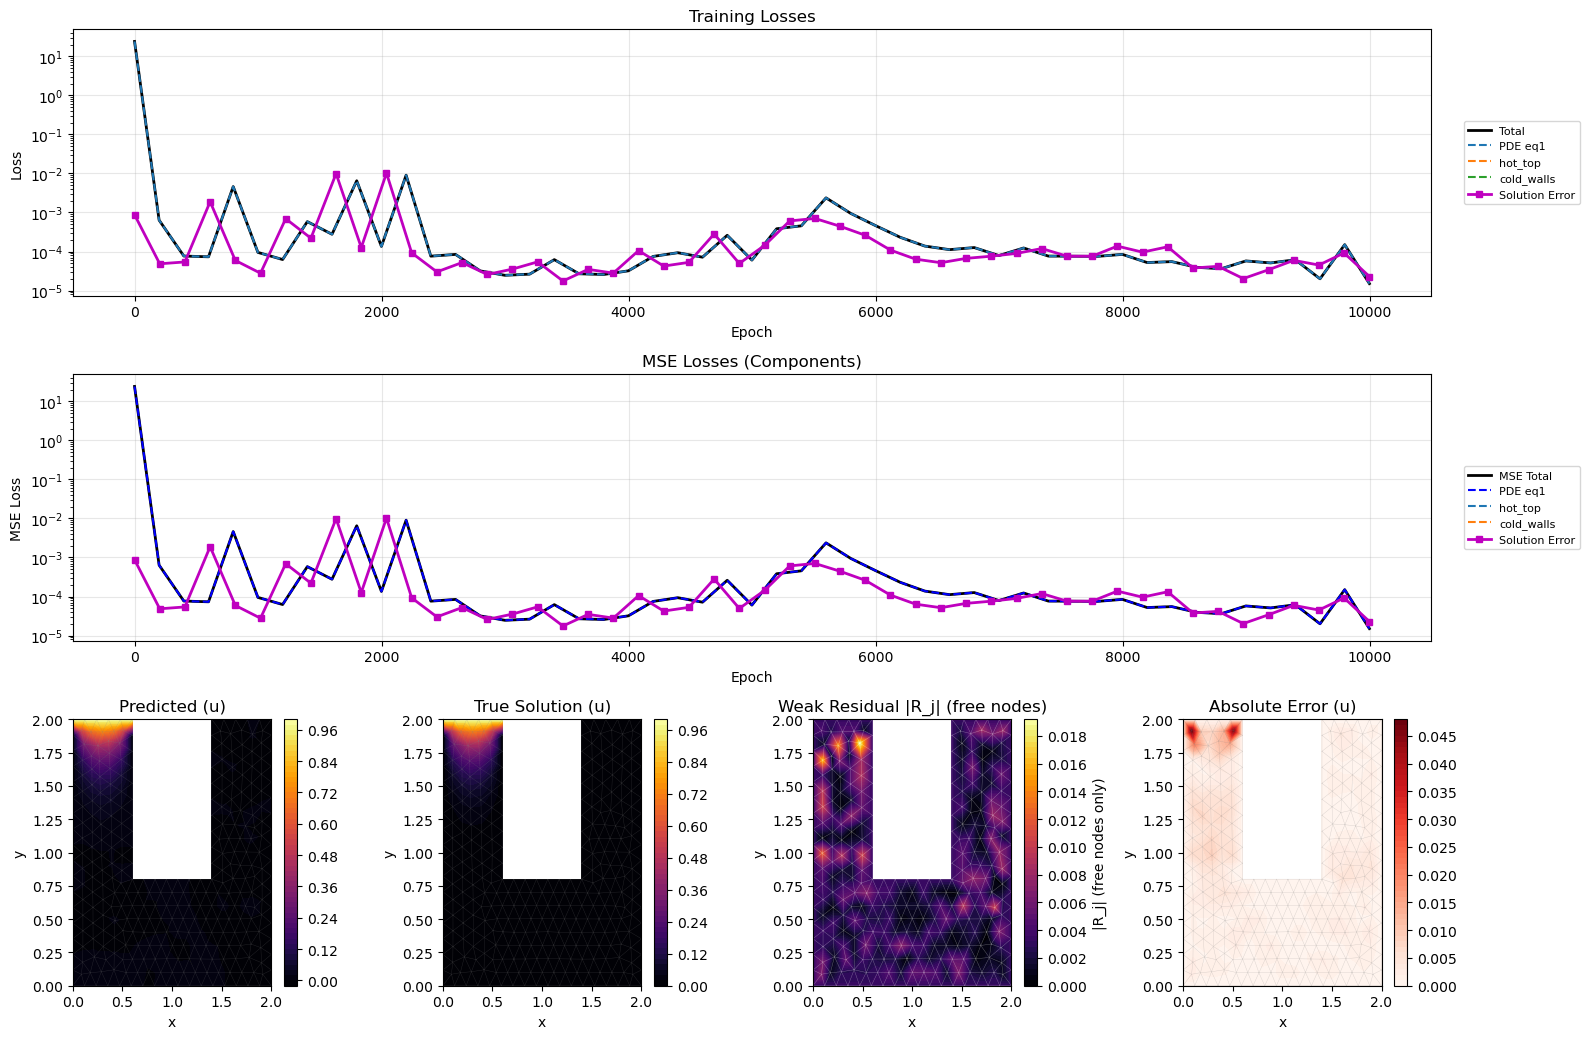

Starting Trainer (JAX, Lagrangian mode) for 10000 epochs...
Epoch 0/10000 | MSE Loss: 2.40e+01 | PDE: 2.40e+01 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00]
Epoch 200/10000 | AL Loss: 7.09e-04 | MSE Loss: 6.35e-04 | PDE: 6.35e-04 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 10.3s | Error: 8.75e-04
Epoch 400/10000 | AL Loss: 8.09e-05 | MSE Loss: 7.66e-05 | PDE: 7.66e-05 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 12.0s | Error: 4.85e-05
Epoch 600/10000 | AL Loss: 6.14e-05 | MSE Loss: 7.32e-05 | PDE: 7.32e-05 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 13.6s | Error: 5.40e-05
Epoch 800/10000 | AL Loss: 4.60e-03 | MSE Loss: 4.60e-03 | PDE: 4.60e-03 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 15.2s | Error: 1.89e-03
Epoch 1000/10000 | AL Loss: 8.71e-05 | MSE Loss: 9.48e-05 | PDE: 9.48e-05 | BCs: [hot_top: 0.00e+00, cold_walls: 0.00e+00] | Time: 16.9s | Error: 5.91e-05
Epoch 1200/10000 | AL Loss: 5.41e-05 | MSE Loss: 6.23e-05 | PDE: 6.23

In [ ]:
trainer = Trainer(problem, net)
trainer.compile(
    epochs=20000,
    weights={"pde": 1.0},
    learning_rate=1e-3,
    lagrange_lr=1e-4,
    print_each=200,
    show_plots=True,
)
trainer.train()
